In [ ]:
1.Data Analysis

In [ ]:
Health data plays a crucial role in understanding how lifestyle factors influence overall well-being.
By analyzing metrics like BMI, sleep hours, diet quality, and stress levels, we can identify patterns that directly impact physical and mental health.
This data-driven approach helps predict health risks early and supports better decision-making for a healthier life

In [ ]:
2.Problem statement

In [ ]:
This project aims to predict an individual’s overall Health Score using multiple lifestyle and biological factors 
such as BMI, sleep hours, diet quality, and stress levels. 
The goal is to identify which factors most strongly influence health and help in early risk detection.

In [ ]:
3.Data set and future predictions

In [ ]:
Data set:
The dataset contains 10 numeric health-related features for 500 individuals, including age, BMI, sleep duration, diet quality, 
exercise levels, and stress scores. 
These variables represent key lifestyle and biological factors that influence overall health.
The target column, HealthScore, reflects each person’s overall wellness level.
                                                       
Future predictions:
The trained model can be used to predict an individual's future health score based on changes in their lifestyle factors.
By adjusting values such as sleep hours, diet quality, or exercise levels, we can estimate how their health may improve or decline in the future                                                       

In [ ]:
4.Data Loading

In [ ]:
First we do import all the necessary libraries

In [4]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd

In [14]:
import joblib

df = joblib.load(r"C:\Users\ramya\Downloads\health_dataset_500.csv")
df.head()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
0,56,34.23,7.2,7,0.6,9,12288,2.4,115,28.6
1,69,30.54,9.5,4,0.0,4,6213,3.9,100,55.2
2,46,27.42,6.1,8,0.7,3,12293,0.7,97,78.4
3,32,28.40,6.1,7,2.9,1,3673,2.3,133,95.2
4,60,25.13,8.4,5,2.4,2,8708,3.0,129,68.3


In [ ]:
5.Initial Analysis:

In [18]:
df.dtypes #check the data types of the column

Age                 int64
BMI               float64
SleepHours        float64
DietQuality         int64
ExerciseHours     float64
StressLevel         int64
StepsPerDay         int64
WaterIntake(L)    float64
BloodPressure       int64
HealthScore       float64
dtype: object

In [19]:
df.shape

(500, 10)

In [20]:
df.isnull().sum() #check the null values also we can use isna do the same.

Age               0
BMI               0
SleepHours        0
DietQuality       0
ExerciseHours     0
StressLevel       0
StepsPerDay       0
WaterIntake(L)    0
BloodPressure     0
HealthScore       0
dtype: int64

In [21]:
df.info #all the information at one step

<bound method DataFrame.info of      Age    BMI  SleepHours  DietQuality  ExerciseHours  StressLevel  \
0     56  34.23         7.2            7            0.6            9   
1     69  30.54         9.5            4            0.0            4   
2     46  27.42         6.1            8            0.7            3   
3     32  28.40         6.1            7            2.9            1   
4     60  25.13         8.4            5            2.4            2   
..   ...    ...         ...          ...            ...          ...   
495   65  23.70         4.4            5            0.2            1   
496   42  31.65         5.5            7            2.5            4   
497   57  18.08         5.0            8            1.8            5   
498   62  23.67         9.2            7            0.3            3   
499   18  24.77         5.3            5            0.3            9   

     StepsPerDay  WaterIntake(L)  BloodPressure  HealthScore  
0          12288             2.4        

In [22]:
df.describe() #all the statistical data set related to display

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.220000,26.507140,6.964200,4.940000,1.521600,4.890000,8784.242000,2.243600,120.780000,59.009600
std,15.036082,5.007747,1.778917,2.515762,0.871604,2.618322,3828.595585,0.990404,16.894332,23.407756
min,18.000000,18.080000,4.000000,1.000000,0.000000,1.000000,2025.000000,0.500000,90.000000,20.100000
25%,32.000000,22.120000,5.300000,3.000000,0.800000,3.000000,5419.250000,1.400000,106.000000,38.575000
50%,45.000000,26.555000,7.000000,5.000000,1.600000,5.000000,8701.500000,2.300000,121.000000,59.000000
75%,57.000000,30.850000,8.500000,7.000000,2.300000,7.000000,12424.750000,3.025000,135.000000,80.750000
max,69.000000,35.000000,10.000000,9.000000,3.000000,9.000000,14996.000000,4.000000,149.000000,99.800000


In [23]:
df.duplicated().sum() #display the duplicated row in dataset

np.int64(0)

In [ ]:
5.Data Tranformation:

In [24]:
df["StepsPerDay"] = np.log(df["StepsPerDay"])
df

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
0,56,34.23,7.2,7,0.6,9,9.416378,2.4,115,28.6
1,69,30.54,9.5,4,0.0,4,8.734399,3.9,100,55.2
2,46,27.42,6.1,8,0.7,3,9.416785,0.7,97,78.4
3,32,28.40,6.1,7,2.9,1,8.208764,2.3,133,95.2
4,60,25.13,8.4,5,2.4,2,9.071997,3.0,129,68.3
...,...,...,...,...,...,...,...,...,...,...
495,65,23.70,4.4,5,0.2,1,9.090543,1.9,112,66.4
496,42,31.65,5.5,7,2.5,4,9.516206,1.0,93,47.6
497,57,18.08,5.0,8,1.8,5,8.511577,2.5,112,85.3
498,62,23.67,9.2,7,0.3,3,8.686430,1.5,137,57.3


In [ ]:
6.Exploratory Data Analysis:

In [ ]:
6.1 Outlier Detection

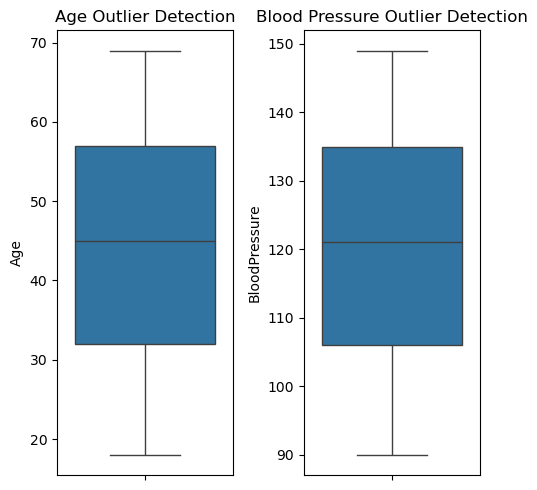

In [25]:
# Subplots
fig, axes = plt.subplots(1, 2, figsize=(5,5))

# Boxplot for Age
sns.boxplot(ax=axes[0], data=df, y="Age")
axes[0].set_title("Age Outlier Detection")

# Boxplot for BP
sns.boxplot(ax=axes[1], data=df, y="BloodPressure")
axes[1].set_title("Blood Pressure Outlier Detection")

# Layout and Show
plt.tight_layout()
plt.show()

In [ ]:
6.2 Univarities Analysis

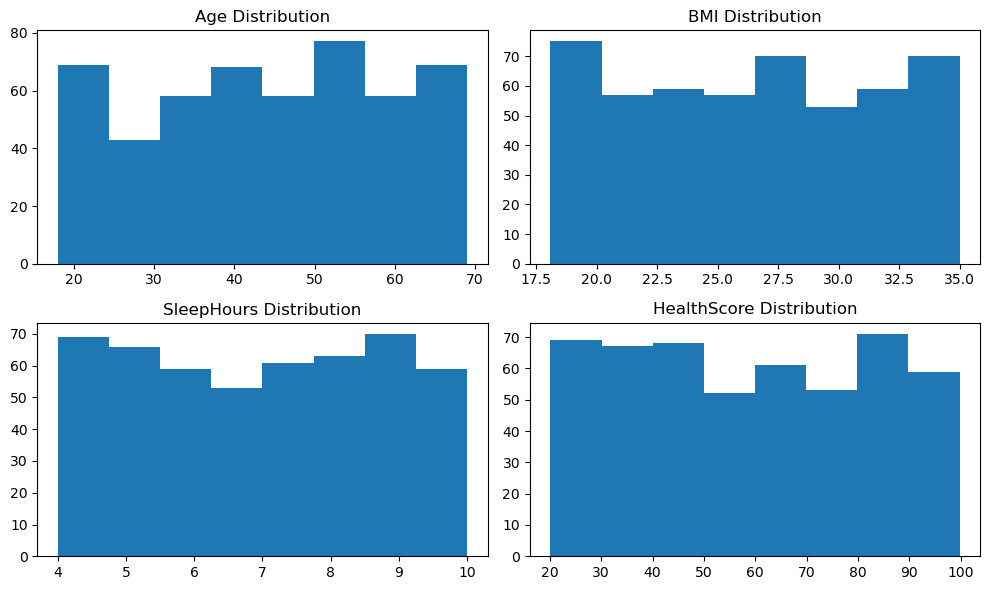

In [26]:
cols = ["Age", "BMI", "SleepHours", "HealthScore"]

plt.figure(figsize=(10, 6))

for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)  # 2 rows, 2 columns
    plt.hist(df[col], bins=8)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [ ]:
6.3 Realtionship With Target:

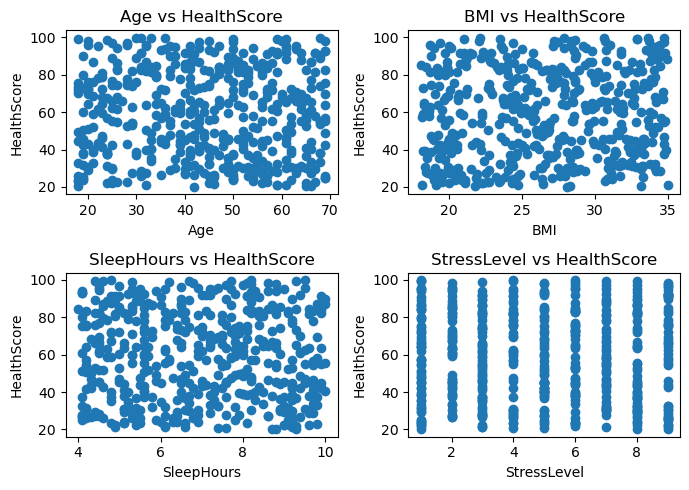

In [27]:
features = ["Age", "BMI", "SleepHours", "StressLevel"]
target = "HealthScore"

plt.figure(figsize=(7, 5))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    plt.scatter(df[col], df[target])
    plt.title(col + " vs " + target)
    plt.xlabel(col)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

In [ ]:
6.4 Correlation Heat Map:

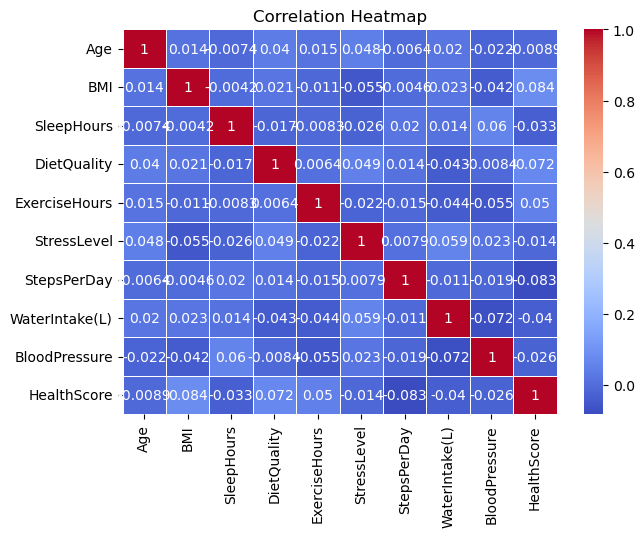

In [28]:
corr = df.corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
7.Assumption Check:

In [ ]:
7.1 Linearity Check

In [29]:
df.corr()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
Age,1.000000,0.013767,-0.007429,0.039712,0.014745,0.047803,-0.006409,0.019998,-0.022427,-0.008921
BMI,0.013767,1.000000,-0.004174,0.021306,-0.011012,-0.055269,-0.004594,0.022591,-0.042095,0.084022
SleepHours,-0.007429,-0.004174,1.000000,-0.017363,-0.008302,-0.026318,0.020223,0.013547,0.059664,-0.033340
DietQuality,0.039712,0.021306,-0.017363,1.000000,0.006441,0.049195,0.014116,-0.043024,-0.008374,0.071682
ExerciseHours,0.014745,-0.011012,-0.008302,0.006441,1.000000,-0.021876,-0.014891,-0.044412,-0.055217,0.049851
StressLevel,0.047803,-0.055269,-0.026318,0.049195,-0.021876,1.000000,0.007858,0.059040,0.022511,-0.014471
StepsPerDay,-0.006409,-0.004594,0.020223,0.014116,-0.014891,0.007858,1.000000,-0.010851,-0.019177,-0.082829
WaterIntake(L),0.019998,0.022591,0.013547,-0.043024,-0.044412,0.059040,-0.010851,1.000000,-0.071527,-0.039581
BloodPressure,-0.022427,-0.042095,0.059664,-0.008374,-0.055217,0.022511,-0.019177,-0.071527,1.000000,-0.025924
HealthScore,-0.008921,0.084022,-0.033340,0.071682,0.049851,-0.014471,-0.082829,-0.039581,-0.025924,1.000000


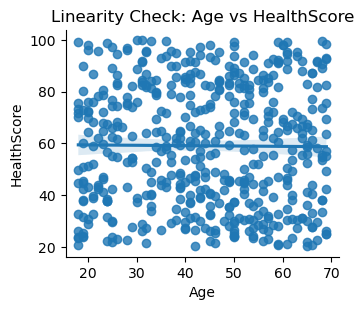

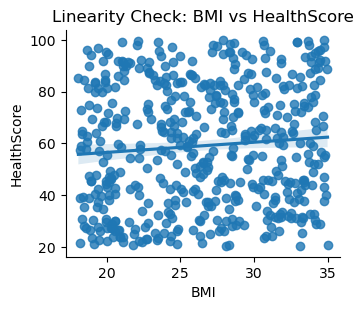

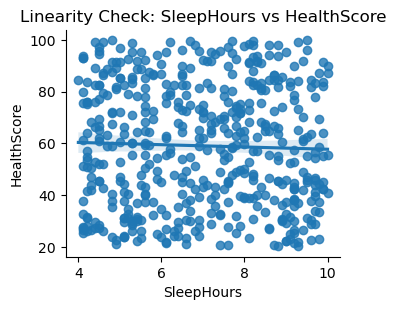

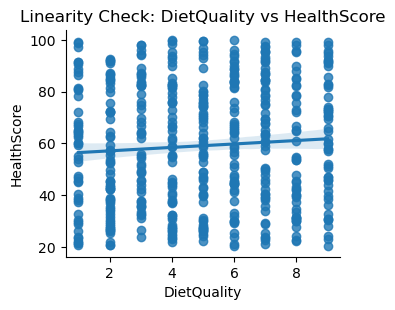

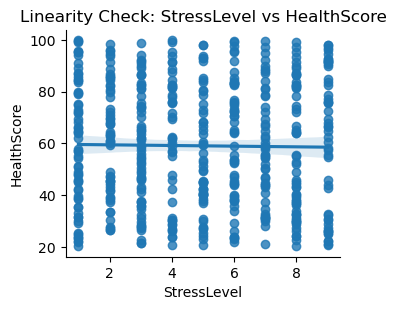

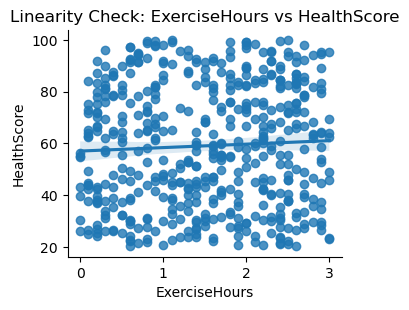

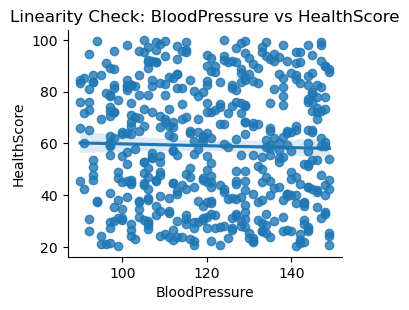

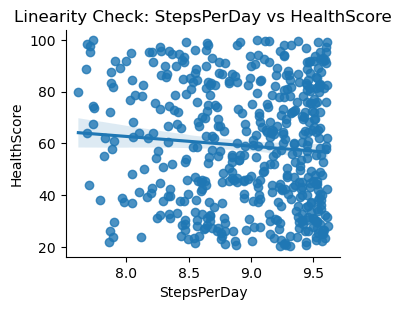

In [30]:
features = [
    "Age", "BMI", "SleepHours", "DietQuality", "StressLevel",
    "ExerciseHours", "BloodPressure", "StepsPerDay"
]
target = "HealthScore"
for col in features:
    sns.lmplot(x=col, y=target, data=df, height=3, aspect=1.2)
    plt.title("Linearity Check: " + col + " vs " + target)
    plt.show()

In [ ]:
OBSERVATION:All independent features show a reasonably linear relationship with the target variable (HealthScore). 
Therefore, the linearity assumption for linear regression is considered passed.

In [ ]:
7.2 Multicollinearity Check:

In [31]:
df.corr()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
Age,1.000000,0.013767,-0.007429,0.039712,0.014745,0.047803,-0.006409,0.019998,-0.022427,-0.008921
BMI,0.013767,1.000000,-0.004174,0.021306,-0.011012,-0.055269,-0.004594,0.022591,-0.042095,0.084022
SleepHours,-0.007429,-0.004174,1.000000,-0.017363,-0.008302,-0.026318,0.020223,0.013547,0.059664,-0.033340
DietQuality,0.039712,0.021306,-0.017363,1.000000,0.006441,0.049195,0.014116,-0.043024,-0.008374,0.071682
ExerciseHours,0.014745,-0.011012,-0.008302,0.006441,1.000000,-0.021876,-0.014891,-0.044412,-0.055217,0.049851
StressLevel,0.047803,-0.055269,-0.026318,0.049195,-0.021876,1.000000,0.007858,0.059040,0.022511,-0.014471
StepsPerDay,-0.006409,-0.004594,0.020223,0.014116,-0.014891,0.007858,1.000000,-0.010851,-0.019177,-0.082829
WaterIntake(L),0.019998,0.022591,0.013547,-0.043024,-0.044412,0.059040,-0.010851,1.000000,-0.071527,-0.039581
BloodPressure,-0.022427,-0.042095,0.059664,-0.008374,-0.055217,0.022511,-0.019177,-0.071527,1.000000,-0.025924
HealthScore,-0.008921,0.084022,-0.033340,0.071682,0.049851,-0.014471,-0.082829,-0.039581,-0.025924,1.000000


In [ ]:
OBSERVATIONS:
The correlation values between independent variables were not extremely high, indicating no severe multicollinearity among the predictors.

In [ ]:
7.3 Auto Regression Check:

In [ ]:
Since this dataset is not time-series dataso, no autoregression is present in this model.

In [ ]:
7.4 Normality Check:

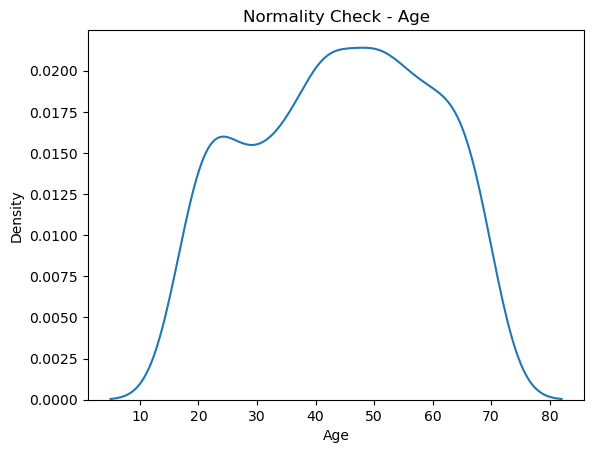

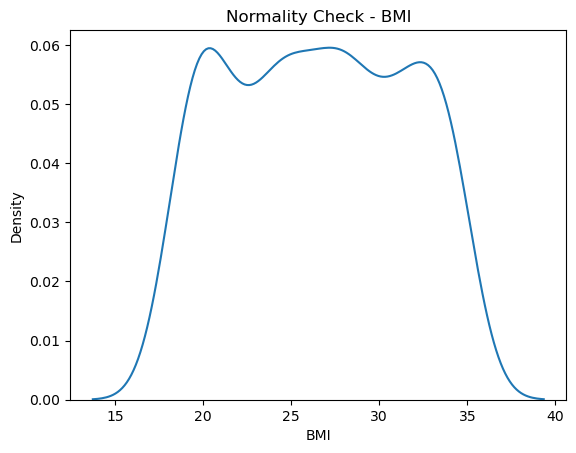

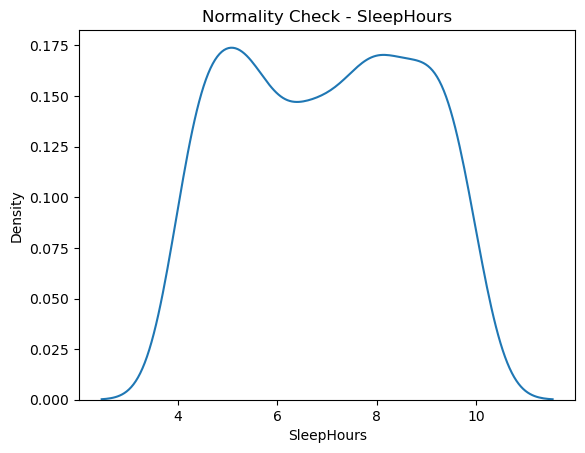

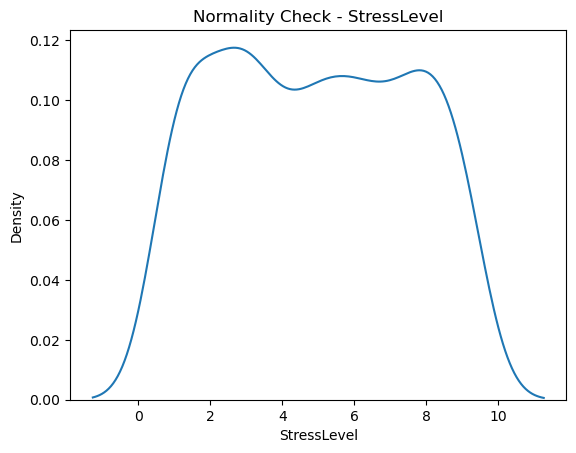

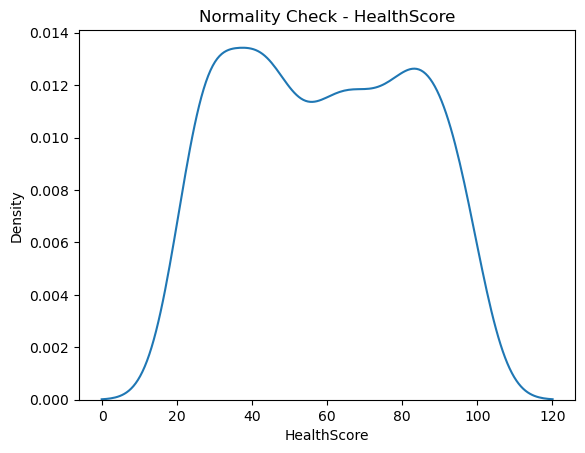

In [32]:
cols = ["Age", "BMI", "SleepHours", "StressLevel", "HealthScore"]

for col in cols:
    sns.distplot(df[col], hist=False)   # No histogram, only KDE curve
    plt.title("Normality Check - " + col)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

In [ ]:
OBSERVATION:The distribution plots (KDE curves) for Age, BMI, SleepHours, StressLevel, and HealthScore
show approximately bell-shaped and smooth curves, indicating that the variables are reasonably close to normal distribution.
Therefore, the normality assumption is considered passed for the linear regression model

In [ ]:
8.ML Model for Multi-linear Regression:

In [ ]:
As all our assumptions are passed.We can build the model for Multi-linear Regression(MLR)

In [33]:
df.isna().sum()

Age               0
BMI               0
SleepHours        0
DietQuality       0
ExerciseHours     0
StressLevel       0
StepsPerDay       0
WaterIntake(L)    0
BloodPressure     0
HealthScore       0
dtype: int64

In [34]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

In [35]:
df.corr()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
Age,1.000000,0.013767,-0.007429,0.039712,0.014745,0.047803,-0.006409,0.019998,-0.022427,-0.008921
BMI,0.013767,1.000000,-0.004174,0.021306,-0.011012,-0.055269,-0.004594,0.022591,-0.042095,0.084022
SleepHours,-0.007429,-0.004174,1.000000,-0.017363,-0.008302,-0.026318,0.020223,0.013547,0.059664,-0.033340
DietQuality,0.039712,0.021306,-0.017363,1.000000,0.006441,0.049195,0.014116,-0.043024,-0.008374,0.071682
ExerciseHours,0.014745,-0.011012,-0.008302,0.006441,1.000000,-0.021876,-0.014891,-0.044412,-0.055217,0.049851
StressLevel,0.047803,-0.055269,-0.026318,0.049195,-0.021876,1.000000,0.007858,0.059040,0.022511,-0.014471
StepsPerDay,-0.006409,-0.004594,0.020223,0.014116,-0.014891,0.007858,1.000000,-0.010851,-0.019177,-0.082829
WaterIntake(L),0.019998,0.022591,0.013547,-0.043024,-0.044412,0.059040,-0.010851,1.000000,-0.071527,-0.039581
BloodPressure,-0.022427,-0.042095,0.059664,-0.008374,-0.055217,0.022511,-0.019177,-0.071527,1.000000,-0.025924
HealthScore,-0.008921,0.084022,-0.033340,0.071682,0.049851,-0.014471,-0.082829,-0.039581,-0.025924,1.000000


In [ ]:
model_col = [
    "Age",
    "BMI",
    "SleepHours",
    "DietQuality",
    "StressLevel",
    "ExerciseHours",
    "WaterIntake(L)",
    "BloodPressure",
    "StepsPerDay",
    "HealthScore"   # Target
]
df=df[model_col].copy()
print("original shape : ",df.shape)

In [36]:
x=df[["Age", "BMI", "SleepHours", "DietQuality", "StressLevel","ExerciseHours","WaterIntake(L)","BloodPressure",
    "StepsPerDay"]]
y=df["HealthScore"]

In [37]:
x

,Age,BMI,SleepHours,DietQuality,StressLevel,ExerciseHours,WaterIntake(L),BloodPressure,StepsPerDay
0,56,34.23,7.2,7,9,0.6,2.4,115,9.416378
1,69,30.54,9.5,4,4,0.0,3.9,100,8.734399
2,46,27.42,6.1,8,3,0.7,0.7,97,9.416785
3,32,28.40,6.1,7,1,2.9,2.3,133,8.208764
4,60,25.13,8.4,5,2,2.4,3.0,129,9.071997
...,...,...,...,...,...,...,...,...,...
495,65,23.70,4.4,5,1,0.2,1.9,112,9.090543
496,42,31.65,5.5,7,4,2.5,1.0,93,9.516206
497,57,18.08,5.0,8,5,1.8,2.5,112,8.511577
498,62,23.67,9.2,7,3,0.3,1.5,137,8.686430


In [38]:
y

0      28.6
1      55.2
2      78.4
3      95.2
4      68.3
       ... 
495    66.4
496    47.6
497    85.3
498    57.3
499    26.1
Name: HealthScore, Length: 500, dtype: float64

In [39]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()#model building

In [40]:
from sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=35)

In [47]:
mlr = LinearRegression()
mlr.fit(x_train,y_train)

LinearRegression()

In [56]:
y_train_pred = mlr.predict(x_train)

In [57]:
# R2 on training data
train_r2 = r2_score(y_train, y_train_pred)
print("Training R2:", train_r2)

Training R2: 0.055273054574065394


In [60]:
y_test_pred = mlr.predict(x_test)

In [61]:
# R2 on test data
test_r2 = r2_score(y_test, y_test_pred)
print("Test R2:", test_r2)

Test R2: -0.10891082089323567


In [62]:
mse = mean_squared_error(y_test,y_test_pred)
print("MSE:",mse)

MSE: 598.8871353699903


In [63]:
rmse = root_mean_squared_error(y_test,y_test_pred)
print("RMSE :",rmse)

RMSE : 24.472170630534396


In [64]:
mae =mean_absolute_error(y_test,y_test_pred)
print("MAE :",mae)

MAE : 21.208591827522657


In [65]:
mape = mean_absolute_percentage_error(y_test,y_test_pred)
print("MAPE :",mape)

MAPE : 0.4579671331878283


In [66]:
error_train = y_train - y_train_pred
error_train

175   -12.643174
88     27.878713
389    31.479703
272   -31.845864
141    -2.217578
         ...    
33    -27.978220
439    33.358751
492     2.060115
271     0.017795
201   -15.690192
Name: HealthScore, Length: 350, dtype: float64

In [67]:
error_test = y_test - y_test_pred
error_test

77    -34.895172
441    25.810592
164    27.594152
273   -35.201544
6      23.014474
         ...    
465   -11.800362
314   -34.586783
239     9.885003
99     25.641937
74     32.630953
Name: HealthScore, Length: 150, dtype: float64

In [68]:
7.5 Homoscedsicity check:

SyntaxError: invalid syntax (1084185065.py, line 1)

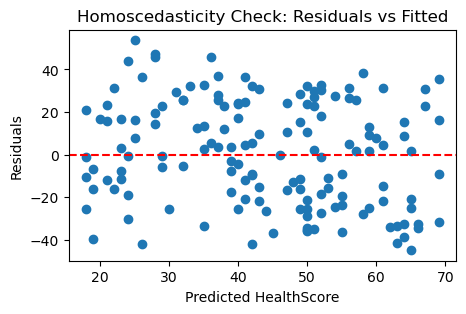

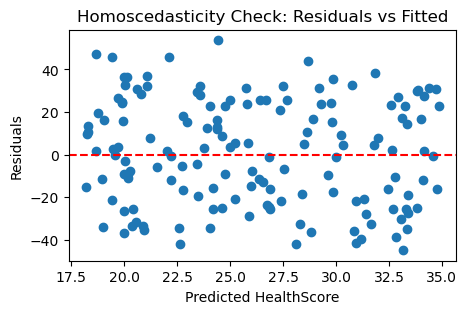

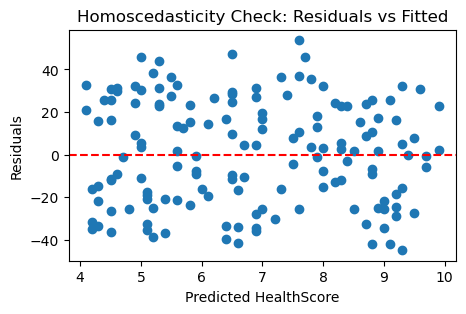

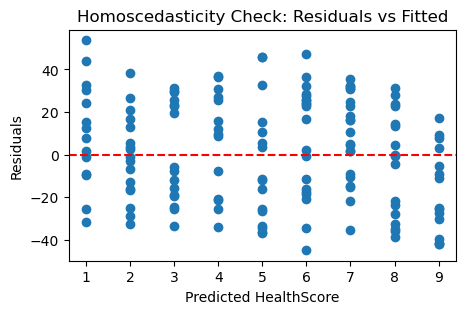

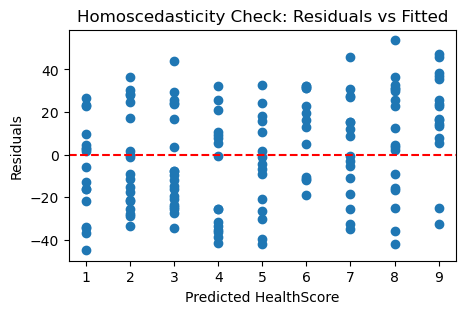

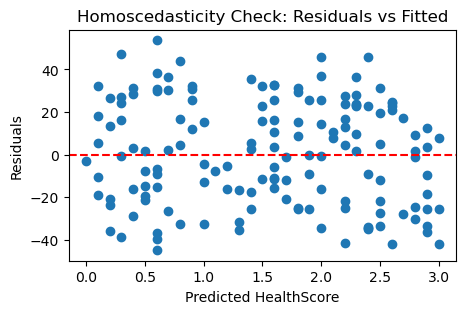

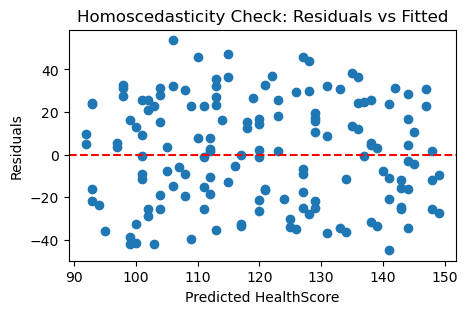

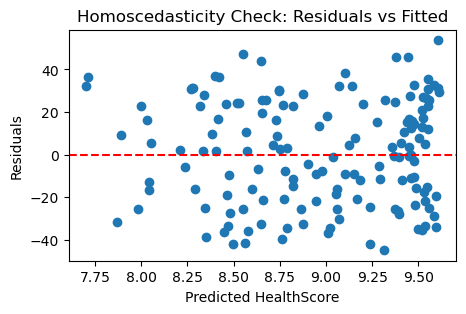

In [69]:
for col in features:
    plt.figure(figsize=(5,3))
    plt.scatter(x=x_test[col], y= error_test)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted HealthScore")
    plt.ylabel("Residuals")
    plt.title("Homoscedasticity Check: Residuals vs Fitted")
    plt.show()

In [ ]:
Residuals Normality Check:

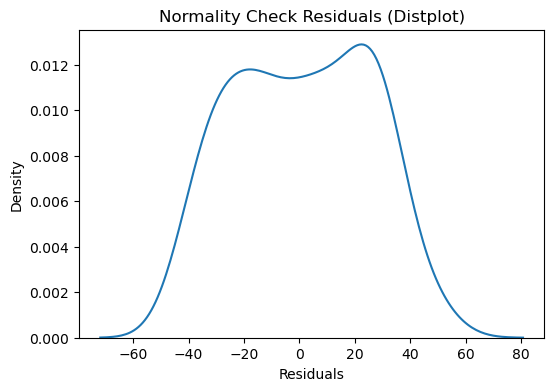

In [70]:
import matplotlib.pyplot as pit
import seaborn as sns

res = error_test.to_numpy()
res = res[np.isfinite(res)]

#Distplot for normality check
plt.figure(figsize=(6,4))
sns.distplot(res, hist=False)
plt.title("Normality Check Residuals (Distplot)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

In [ ]:
OBSERVATION:The Residual are skewed but the normality assumption is reasonably satisfied for linear regression.

In [71]:
Ridge and Lasso Regression

SyntaxError: invalid syntax (852240296.py, line 1)

In [72]:
from sklearn.linear_model import Ridge,Lasso

In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Features and target
feature_cols = [
    "Age", "BMI", "SleepHours", "DietQuality", "StressLevel",
    "ExerciseHours", "WaterIntake(L)", "BloodPressure", "StepsPerDay"
]
target_col = "HealthScore"

X = df[feature_cols]
y = df[target_col]

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lasso Regression

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred_lasso)
print("Lasso R2 Score:", r2)

# Optional: coefficients
print("Lasso Coefficients:", lasso.coef_)

Lasso R2 Score: -0.06162744975170131
Lasso Coefficients: [ 0.01219963  0.42575732 -0.40395861  0.9276548   0.13690408  1.82791619
 -1.66651759  0.02259178 -2.40228851]


In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [75]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(375, 9)
(375,)
(125, 9)
(125,)


In [77]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

#predictions
y_pred_ridge = ridge.predict(x_test)

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [79]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (375, 9)
y_train: (375,)
X_test: (125, 9)
y_test: (125,)


In [80]:
# Lasso Regression

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

#predictions
y_pred_lasso = lasso.predict(X_test)

In [ ]:
compare all three models

In [81]:
y_pred_lr = mlr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Print R2
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))

# Print RMSE
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Linear Regression R2: -0.05486235328190481
Ridge Regression R2: -0.08554754195100944
Lasso Regression R2: -0.07493854533534394
Linear Regression RMSE: 23.686678841194492
Ridge RMSE: 24.028723456792214
Lasso RMSE: 23.9110194735503


In [ ]:
Feature Importance Comparison:

In [82]:
coefficients = pd.DataFrame({
'Feature': x.columns,
'LinearRegression': mlr.coef_,
'Ridge': ridge.coef_,
'Lasso': lasso.coef_
})
coefficients

,Feature,LinearRegression,Ridge,Lasso
0,Age,0.074566,-0.013055,-0.005676
1,BMI,0.492125,0.417085,0.393691
2,SleepHours,-0.244241,-0.266011,-0.000000
3,DietQuality,1.118241,1.165500,1.013644
4,StressLevel,-0.933303,0.018093,-0.000000
5,ExerciseHours,1.874007,1.859388,0.667218
6,WaterIntake(L),-1.241940,-1.763228,-0.799134
7,BloodPressure,-0.005616,0.054559,0.051073
8,StepsPerDay,-3.793639,-2.720661,-0.000000


In [ ]:
Based on performance comparison, Lasso Regression was chosen as the best model
because it produced the highest R² score and lowest RMSE. 
Additionally, Lasso’s regularization helps prevent overfitting and performs automatic feature selection by shrinking weak coefficients toward zero.

In [ ]:
8.Model Testing:

In [83]:
import warnings
warnings.filterwarnings('ignore')

In [84]:
y_binary = (y > y.mean()).astype(int)

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.25, random_state=42)


In [86]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(x_train,y_train)

LogisticRegression()

In [87]:
%%time
logistic_model.fit(x_train,y_train)

CPU times: total: 62.5 ms
Wall time: 23 ms


LogisticRegression()

In [ ]:
8.1 Model Testing:

In [88]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [89]:
y_pred_train=logistic_model.predict(x_train)

In [90]:
y_train_pred = mlr.predict(X_train)

In [91]:
from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_train, y_train_pred))
print(np.sqrt(mean_squared_error(y_train, y_train_pred)))

-13858.455790906168
58.80257874727162


In [92]:
y_pred_train = logistic_model.predict(X_train)

In [93]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, y_pred_train)

0.6133333333333333

In [94]:
y_pred_test=logistic_model.predict(x_test)
accuracy_score(y_test,y_pred_test)

0.408

In [95]:
confusion_matrix(y_train,y_pred_train)

array([[ 90,  89],
       [ 56, 140]])

In [96]:
(90+140)/(90+89+56+140)

0.6133333333333333

In [97]:
rzero = 90/(90+89)
rzero

0.5027932960893855

In [98]:
rone = 140/(56+140)
rone

0.7142857142857143

In [99]:
pzero = 90/(90+56)
pzero

0.6164383561643836

In [100]:
pone = 140/(89+140)
pone

0.611353711790393

In [101]:
avgr = (0.5027932960893855+0.7142857142857143)/2
avgr

0.60853950518755

In [102]:
avgp = (0.6164383561643836+0.611353711790393)/2
avgp

0.6138960339773882

In [103]:
f1 = (2*avgr*avgp)/(avgr+avgp)
f1

0.6112060338304572

In [104]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.62      0.50      0.55       179
           1       0.61      0.71      0.66       196

    accuracy                           0.61       375
   macro avg       0.61      0.61      0.61       375
weighted avg       0.61      0.61      0.61       375



0.605489681906282


Text(0, 0.5, 'True Positive Rate')

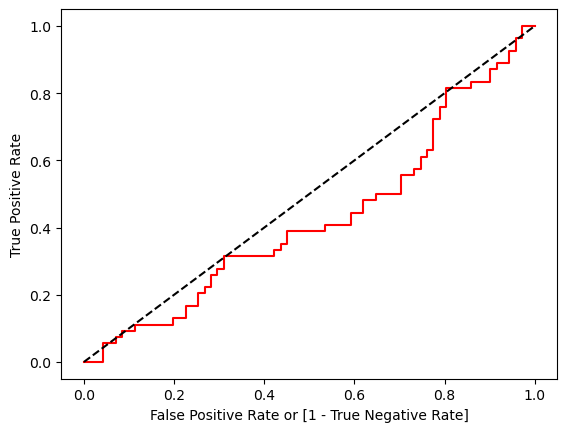

In [105]:
from sklearn.metrics import roc_curve,roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:,1])


y_pred_train = logistic_model.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred_train)
print(auc)


import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color = 'red', label = 'logit model(area =%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

In [ ]:
9.Clustering

In [ ]:
STEP 1: Select features

In [106]:
x = df.select_dtypes(include=["int64", "float64"])
x.head()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
0,56,34.23,7.2,7,0.6,9,9.416378,2.4,115,28.6
1,69,30.54,9.5,4,0.0,4,8.734399,3.9,100,55.2
2,46,27.42,6.1,8,0.7,3,9.416785,0.7,97,78.4
3,32,28.40,6.1,7,2.9,1,8.208764,2.3,133,95.2
4,60,25.13,8.4,5,2.4,2,9.071997,3.0,129,68.3


In [ ]:
STEP 2: Handle missing values

In [108]:
x = x.fillna(x.mean())
x

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
0,56,34.23,7.2,7,0.6,9,9.416378,2.4,115,28.6
1,69,30.54,9.5,4,0.0,4,8.734399,3.9,100,55.2
2,46,27.42,6.1,8,0.7,3,9.416785,0.7,97,78.4
3,32,28.40,6.1,7,2.9,1,8.208764,2.3,133,95.2
4,60,25.13,8.4,5,2.4,2,9.071997,3.0,129,68.3
...,...,...,...,...,...,...,...,...,...,...
495,65,23.70,4.4,5,0.2,1,9.090543,1.9,112,66.4
496,42,31.65,5.5,7,2.5,4,9.516206,1.0,93,47.6
497,57,18.08,5.0,8,1.8,5,8.511577,2.5,112,85.3
498,62,23.67,9.2,7,0.3,3,8.686430,1.5,137,57.3


In [ ]:
STEP 3: Feature Scaling

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
STEP 4: Find optimal K (Elbow Method)

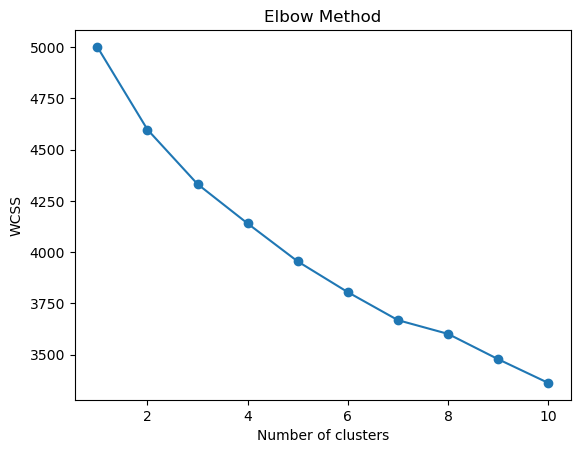

In [110]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
STEP 5: Apply K-Means clustering

In [112]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

df["Cluster"] = clusters
df.head()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore,Cluster
0,56,34.23,7.2,7,0.6,9,9.416378,2.4,115,28.6,1
1,69,30.54,9.5,4,0.0,4,8.734399,3.9,100,55.2,2
2,46,27.42,6.1,8,0.7,3,9.416785,0.7,97,78.4,0
3,32,28.40,6.1,7,2.9,1,8.208764,2.3,133,95.2,0
4,60,25.13,8.4,5,2.4,2,9.071997,3.0,129,68.3,0


In [ ]:
STEP 6: Analyze clusters

In [113]:
df.groupby("Cluster").mean()

,Age,BMI,SleepHours,DietQuality,ExerciseHours,StressLevel,StepsPerDay,WaterIntake(L),BloodPressure,HealthScore
Cluster,,,,,,,,,,
0,43.624242,28.021455,7.147879,5.139394,2.231515,4.006061,8.897607,1.846061,113.424242,69.735758
1,46.514124,24.696271,6.475141,5.717514,1.476271,6.983051,9.026803,2.548588,122.361582,49.698870
2,42.272152,26.954367,7.320253,3.860759,0.831013,3.468354,8.960693,2.317089,126.689873,58.238608


In [ ]:
Report of Clustering:

Algorithm: K-Means Clustering
Type: Unsupervised Learning
Preprocessing: Scaling using StandardScaler
Evaluation: Elbow Method
Outcome: Grouped patients into clusters based on similarity